# Multi-Layer Fully Connected Network
In this exercise, you will implement a fully connected network with an arbitrary number of hidden layers.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Read through the `FullyConnectedNet` class in the file `cs231n/classifiers/fc_net.py`.

Implement the network initialization, forward pass, and backward pass. Throughout this assignment, you will be implementing layers in `cs231n/layers.py`. You can re-use your implementations for `affine_forward`, `affine_backward`, `relu_forward`, `relu_backward`, and `softmax_loss` from before. For right now, don't worry about implementing dropout or batch/layer normalization yet, as you will add those features later.


阅读文件 `cs231n/classifiers/fc_net.py` 中的 `FullyConnectedNet` 类。

实现网络的初始化、前向传播和反向传播。在整个作业过程中，你将在 `cs231n/layers.py` 中实现层。你可以重新使用之前实现的 `affine_forward`、`affine_backward`、`relu_forward`、`relu_backward` 和 `softmax_loss`。目前，无需担心实现dropout或批量/层归一化，因为这些功能将在以后添加。

In [1]:
# Setup cell.
import time
import numpy as np
import matplotlib.pyplot as plt
from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # Set default size of plots.
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """Returns relative error."""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [2]:
# Load the (preprocessed) CIFAR-10 data.
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

/home/x1879/cs231n/assignment1/cs231n/data_utils.py:16: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


## Initial Loss and Gradient Check

As a sanity check, run the following to check the initial loss and to gradient check the network both with and without regularization. This is a good way to see if the initial losses seem reasonable.

For gradient checking, you should expect to see errors around 1e-7 or less.

## 初始损失和梯度检查

为了进行合理性检查，请运行以下代码以检查初始损失，并对带有和不带有正则化的网络进行梯度检查。这是查看初始损失是否合理的好方法。

对于梯度检查，你应该期望看到大约1e-7或更小的错误。

In [3]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
    print("Running check with reg = ", reg)
    model = FullyConnectedNet(
        [H1, H2],
        input_dim=D,
        num_classes=C,
        reg=reg,
        weight_scale=5e-2,
        dtype=np.float64
    )

    loss, grads = model.loss(X, y)
    print("Initial loss: ", loss)

    # Most of the errors should be on the order of e-7 or smaller.
    # NOTE: It is fine however to see an error for W2 on the order of e-5
    # for the check when reg = 0.0
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print(f"{name} relative error: {rel_error(grad_num, grads[name])}")

Running check with reg =  0
Initial loss:  2.3004790897684924
W1 relative error: 7.696805129597462e-08
W2 relative error: 1.7087519156186903e-05
W3 relative error: 2.9508423550094495e-07
b1 relative error: 4.660094650186831e-09
b2 relative error: 2.085654124402131e-09
b3 relative error: 6.598642296022133e-11
Running check with reg =  3.14
Initial loss:  7.052114776533016
W1 relative error: 7.355058816898759e-09
W2 relative error: 6.86942277940646e-08
W3 relative error: 3.483989247437803e-08
b1 relative error: 1.168319680050491e-08
b2 relative error: 1.7223752732008252e-09
b3 relative error: 2.86824680346369e-10


As another sanity check, make sure your network can overfit on a small dataset of 50 images. First, we will try a three-layer network with 100 units in each hidden layer. In the following cell, tweak the **learning rate** and **weight initialization scale** to overfit and achieve 100% training accuracy within 20 epochs.

(Iteration 1 / 40) loss: 2.291715
(Epoch 0 / 20) train acc: 0.340000; val_acc: 0.097000
(Epoch 1 / 20) train acc: 0.360000; val_acc: 0.095000
(Epoch 2 / 20) train acc: 0.320000; val_acc: 0.118000
(Epoch 3 / 20) train acc: 0.420000; val_acc: 0.132000
(Epoch 4 / 20) train acc: 0.640000; val_acc: 0.141000
(Epoch 5 / 20) train acc: 0.640000; val_acc: 0.166000
(Iteration 11 / 40) loss: 1.097836
(Epoch 6 / 20) train acc: 0.740000; val_acc: 0.158000
(Epoch 7 / 20) train acc: 0.760000; val_acc: 0.150000
(Epoch 8 / 20) train acc: 0.920000; val_acc: 0.167000
(Epoch 9 / 20) train acc: 0.960000; val_acc: 0.186000
(Epoch 10 / 20) train acc: 0.900000; val_acc: 0.173000
(Iteration 21 / 40) loss: 0.284311
(Epoch 11 / 20) train acc: 0.940000; val_acc: 0.179000
(Epoch 12 / 20) train acc: 1.000000; val_acc: 0.194000
(Epoch 13 / 20) train acc: 1.000000; val_acc: 0.189000
(Epoch 14 / 20) train acc: 0.980000; val_acc: 0.171000
(Epoch 15 / 20) train acc: 0.980000; val_acc: 0.178000
(Iteration 31 / 40) loss: 

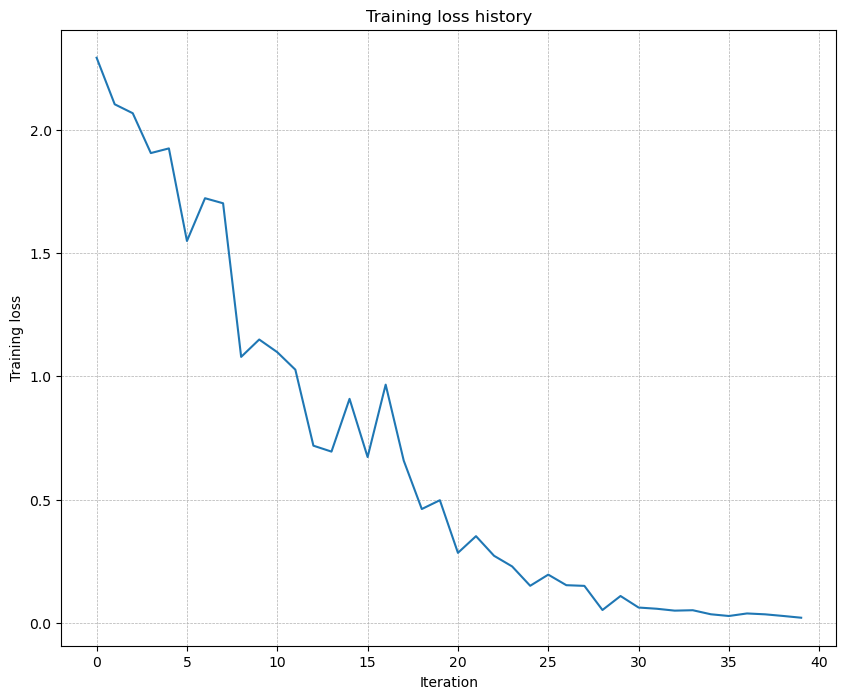

In [7]:
# TODO: Use a three-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  "X_train": data["X_train"][:num_train],
  "y_train": data["y_train"][:num_train],
  "X_val": data["X_val"],
  "y_val": data["y_val"],
}

weight_scale = 1e-2   # Experiment with this!
learning_rate = 1e-2  # Experiment with this!


model = FullyConnectedNet(
    [100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule="sgd",
    optim_config={"learning_rate": learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title("Training loss history")
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

Now, try to use a five-layer network with 100 units on each layer to overfit on 50 training examples. Again, you will have to adjust the learning rate and weight initialization scale, but you should be able to achieve 100% training accuracy within 20 epochs.

(Iteration 1 / 40) loss: 4.510666
(Epoch 0 / 20) train acc: 0.200000; val_acc: 0.095000
(Epoch 1 / 20) train acc: 0.180000; val_acc: 0.092000
(Epoch 2 / 20) train acc: 0.400000; val_acc: 0.107000
(Epoch 3 / 20) train acc: 0.680000; val_acc: 0.154000
(Epoch 4 / 20) train acc: 0.800000; val_acc: 0.152000
(Epoch 5 / 20) train acc: 0.860000; val_acc: 0.138000
(Iteration 11 / 40) loss: 0.913444
(Epoch 6 / 20) train acc: 0.920000; val_acc: 0.152000
(Epoch 7 / 20) train acc: 0.960000; val_acc: 0.133000
(Epoch 8 / 20) train acc: 0.980000; val_acc: 0.145000
(Epoch 9 / 20) train acc: 0.980000; val_acc: 0.143000
(Epoch 10 / 20) train acc: 0.960000; val_acc: 0.144000
(Iteration 21 / 40) loss: 0.133220
(Epoch 11 / 20) train acc: 0.960000; val_acc: 0.129000
(Epoch 12 / 20) train acc: 0.980000; val_acc: 0.152000
(Epoch 13 / 20) train acc: 1.000000; val_acc: 0.136000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.136000
(Epoch 15 / 20) train acc: 1.000000; val_acc: 0.142000
(Iteration 31 / 40) loss: 

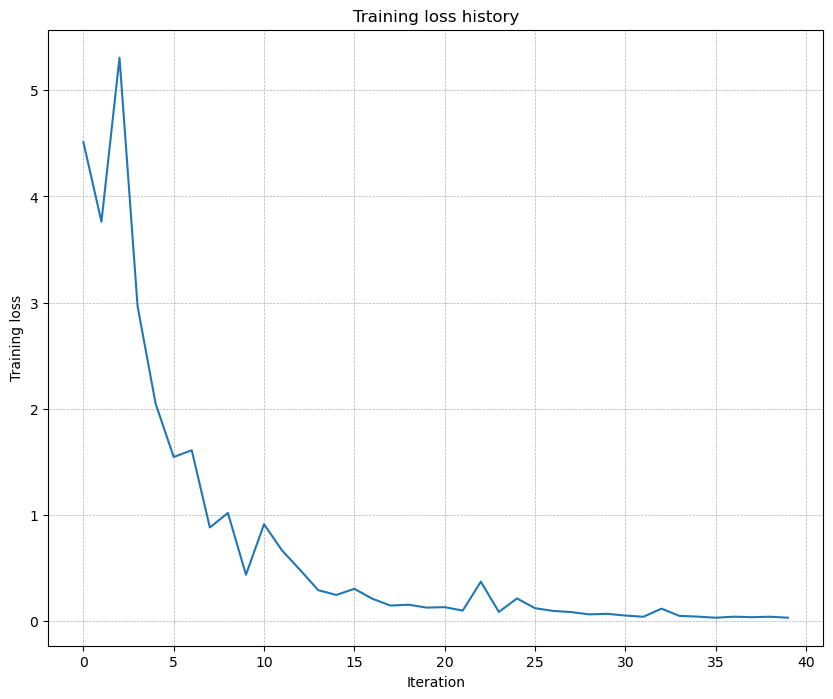

In [28]:
# TODO: Use a five-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

learning_rate = 1e-2  # Experiment with this!
weight_scale = 5e-2   # Experiment with this!


model = FullyConnectedNet(
    [100, 100, 100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule='sgd',
    optim_config={'learning_rate': learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title('Training loss history')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

## Inline Question 1:
Did you notice anything about the comparative difficulty of training the three-layer network vs. training the five-layer network? In particular, based on your experience, which network seemed more sensitive to the initialization scale? Why do you think that is the case?

## Answer:
[FILL THIS IN]




## 行内问题 1：
您是否注意到了训练三层网络与训练五层网络在难度上的比较？特别是根据您的经验，哪个网络对初始化规模更敏感？您认为这是为什么？

## 答案：
[5层,多层网络初始化的细微改变会在多层后被放大]

# Update rules
So far we have used vanilla stochastic gradient descent (SGD) as our update rule. More sophisticated update rules can make it easier to train deep networks. We will implement a few of the most commonly used update rules and compare them to vanilla SGD.

# 更新规则
迄今为止，我们一直使用普通的随机梯度下降（SGD）作为我们的更新规则。更复杂的更新规则可以使训练深层网络变得更加容易。我们将实现一些最常用的更新规则，并将它们与普通的SGD进行比较。

## SGD+Momentum
Stochastic gradient descent with momentum is a widely used update rule that tends to make deep networks converge faster than vanilla stochastic gradient descent. See the Momentum Update section at http://cs231n.github.io/neural-networks-3/#sgd for more information.

Open the file `cs231n/optim.py` and read the documentation at the top of the file to make sure you understand the API. Implement the SGD+momentum update rule in the function `sgd_momentum` and run the following to check your implementation. You should see errors less than e-8.

## SGD+动量
随机梯度下降（SGD）加动量是一种广泛使用的更新规则，它通常比传统的随机梯度下降（vanilla SGD）使深度网络更快地收敛。更多信息请参阅http://cs231n.github.io/neural-networks-3/#sgd中的动量更新部分。

打开文件`cs231n/optim.py`，阅读文件顶部的文档，以确保你理解API。在函数`sgd_momentum`中实现SGD+动量更新规则，并运行以下代码以检查你的实现。你应该看到错误小于e-8。

In [29]:
from cs231n.optim import sgd_momentum

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {"learning_rate": 1e-3, "velocity": v}
next_w, _ = sgd_momentum(w, dw, config=config)

expected_next_w = np.asarray([
  [ 0.1406,      0.20738947,  0.27417895,  0.34096842,  0.40775789],
  [ 0.47454737,  0.54133684,  0.60812632,  0.67491579,  0.74170526],
  [ 0.80849474,  0.87528421,  0.94207368,  1.00886316,  1.07565263],
  [ 1.14244211,  1.20923158,  1.27602105,  1.34281053,  1.4096    ]])
expected_velocity = np.asarray([
  [ 0.5406,      0.55475789,  0.56891579, 0.58307368,  0.59723158],
  [ 0.61138947,  0.62554737,  0.63970526,  0.65386316,  0.66802105],
  [ 0.68217895,  0.69633684,  0.71049474,  0.72465263,  0.73881053],
  [ 0.75296842,  0.76712632,  0.78128421,  0.79544211,  0.8096    ]])

# Should see relative errors around e-8 or less
print("next_w error: ", rel_error(next_w, expected_next_w))
print("velocity error: ", rel_error(expected_velocity, config["velocity"]))

next_w error:  8.882347033505819e-09
velocity error:  4.269287743278663e-09


Once you have done so, run the following to train a six-layer network with both SGD and SGD+momentum. You should see the SGD+momentum update rule converge faster.

Running with  sgd
(Iteration 1 / 200) loss: 2.601051
(Epoch 0 / 5) train acc: 0.078000; val_acc: 0.079000
(Iteration 11 / 200) loss: 2.254162
(Iteration 21 / 200) loss: 2.231545
(Iteration 31 / 200) loss: 2.166922
(Epoch 1 / 5) train acc: 0.243000; val_acc: 0.223000
(Iteration 41 / 200) loss: 2.088200
(Iteration 51 / 200) loss: 1.995169
(Iteration 61 / 200) loss: 2.020006
(Iteration 71 / 200) loss: 1.963023
(Epoch 2 / 5) train acc: 0.283000; val_acc: 0.282000
(Iteration 81 / 200) loss: 2.023185
(Iteration 91 / 200) loss: 1.962690
(Iteration 101 / 200) loss: 1.862494
(Iteration 111 / 200) loss: 1.881997
(Epoch 3 / 5) train acc: 0.377000; val_acc: 0.290000
(Iteration 121 / 200) loss: 1.929788
(Iteration 131 / 200) loss: 2.000984
(Iteration 141 / 200) loss: 1.946444
(Iteration 151 / 200) loss: 1.760986
(Epoch 4 / 5) train acc: 0.350000; val_acc: 0.296000
(Iteration 161 / 200) loss: 1.841901
(Iteration 171 / 200) loss: 1.829335
(Iteration 181 / 200) loss: 1.985434
(Iteration 191 / 200) los

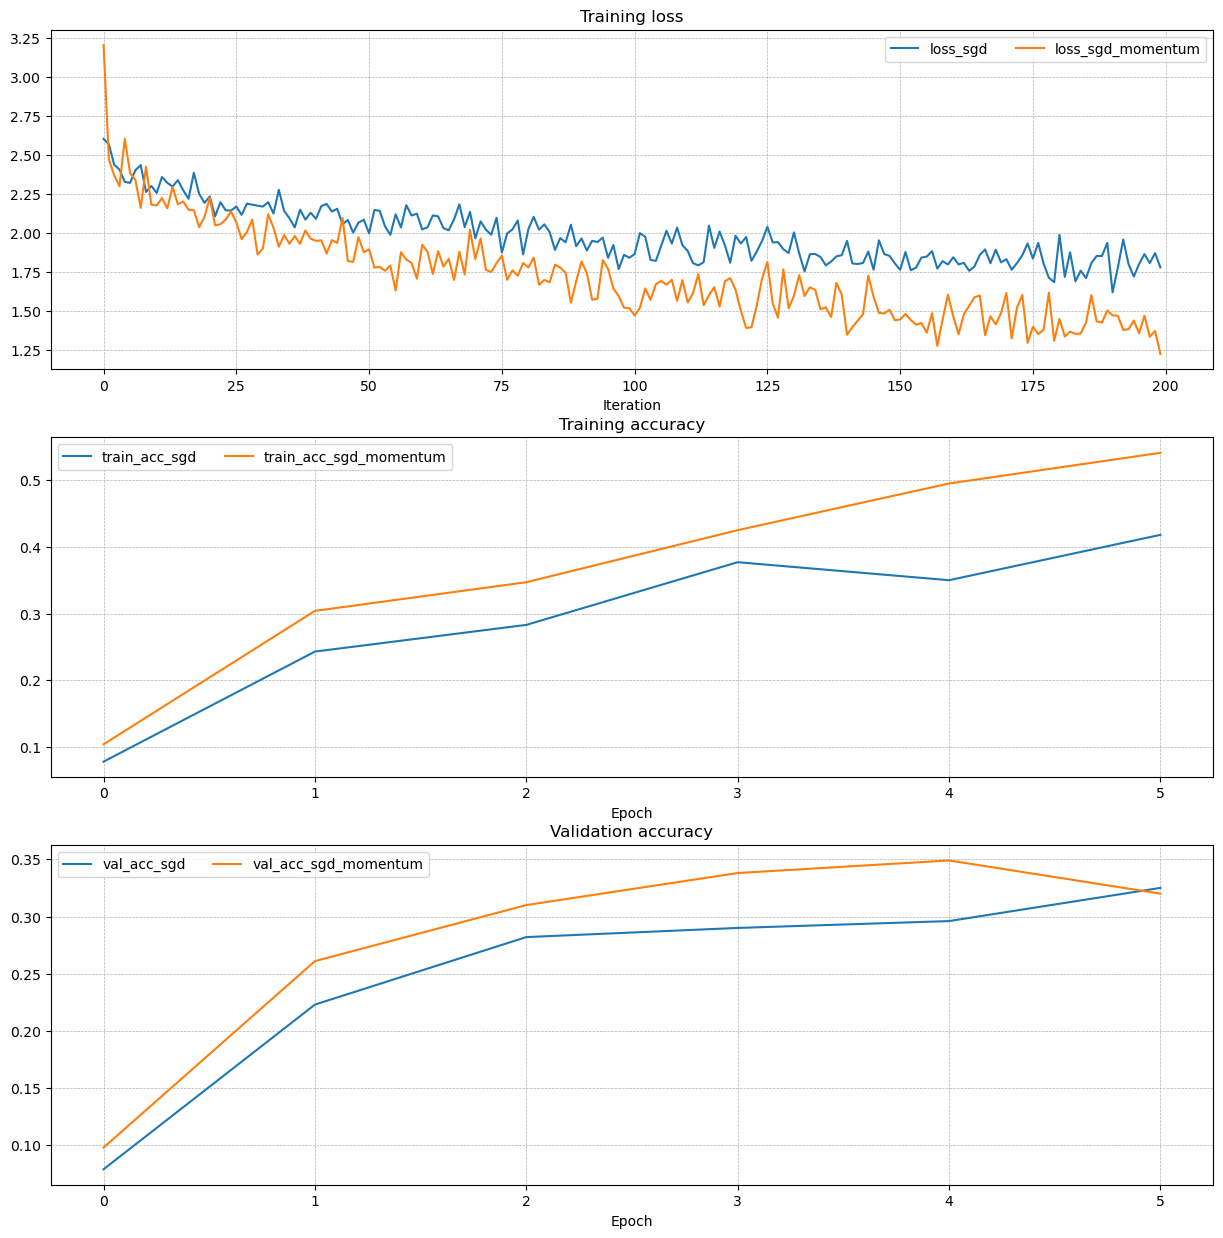

In [30]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )

    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': 5e-3},
        verbose=True,
    )
    solvers[update_rule] = solver
    solver.train()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"loss_{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"train_acc_{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"val_acc_{update_rule}")

for ax in axes:
    ax.legend(loc="best", ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## RMSProp and Adam
RMSProp [1] and Adam [2] are update rules that set per-parameter learning rates by using a running average of the second moments of gradients.

In the file `cs231n/optim.py`, implement the RMSProp update rule in the `rmsprop` function and implement the Adam update rule in the `adam` function, and check your implementations using the tests below.

**NOTE:** Please implement the _complete_ Adam update rule (with the bias correction mechanism), not the first simplified version mentioned in the course notes.

[1] Tijmen Tieleman and Geoffrey Hinton. "Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude." COURSERA: Neural Networks for Machine Learning 4 (2012).

[2] Diederik Kingma and Jimmy Ba, "Adam: A Method for Stochastic Optimization", ICLR 2015.

## RMSProp 和 Adam
RMSProp [1] 和 Adam [2] 是通过使用梯度的二阶矩的运行平均值来设置每个参数的学习率的更新规则。

在文件 `cs231n/optim.py` 中，实现 `rmsprop` 函数以实现 RMSProp 更新规则，并实现 `adam` 函数以实现 Adam 更新规则，并使用下面的测试来检查你的实现。

**注意：** 请实现完整的 Adam 更新规则（包括偏差校正机制），而不是课程笔记中提到的第一个简化的版本。

[1] Tijmen Tieleman 和 Geoffrey Hinton. "Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude." COURSERA: Neural Networks for Machine Learning 4 (2012).

[2] Diederik Kingma 和 Jimmy Ba, "Adam: A Method for Stochastic Optimization", ICLR 2015.

In [33]:
# Test RMSProp implementation
from cs231n.optim import rmsprop

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
  [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
  [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
  [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])
expected_cache = np.asarray([
  [ 0.5976,      0.6126277,   0.6277108,   0.64284931,  0.65804321],
  [ 0.67329252,  0.68859723,  0.70395734,  0.71937285,  0.73484377],
  [ 0.75037008,  0.7659518,   0.78158892,  0.79728144,  0.81302936],
  [ 0.82883269,  0.84469141,  0.86060554,  0.87657507,  0.8926    ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('cache error: ', rel_error(expected_cache, config['cache']))

next_w error:  9.524687511038133e-08
cache error:  2.6477955807156126e-09


In [34]:
# Test Adam implementation
from cs231n.optim import adam

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
m = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)
v = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
  [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
  [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
  [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
  [ 0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853,],
  [ 0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385,],
  [ 0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767,],
  [ 0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966,   ]])
expected_m = np.asarray([
  [ 0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
  [ 0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
  [ 0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
  [ 0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('v error: ', rel_error(expected_v, config['v']))
print('m error: ', rel_error(expected_m, config['m']))

next_w error:  1.1395691798535431e-07
v error:  4.208314038113071e-09
m error:  4.214963193114416e-09


Once you have debugged your RMSProp and Adam implementations, run the following to train a pair of deep networks using these new update rules:

Running with  adam
(Iteration 1 / 200) loss: 2.683611
(Epoch 0 / 5) train acc: 0.117000; val_acc: 0.125000
(Iteration 11 / 200) loss: 2.014160
(Iteration 21 / 200) loss: 1.838017
(Iteration 31 / 200) loss: 1.936847
(Epoch 1 / 5) train acc: 0.350000; val_acc: 0.323000
(Iteration 41 / 200) loss: 1.592235
(Iteration 51 / 200) loss: 1.718598
(Iteration 61 / 200) loss: 1.667453
(Iteration 71 / 200) loss: 1.610000
(Epoch 2 / 5) train acc: 0.429000; val_acc: 0.350000
(Iteration 81 / 200) loss: 1.674492
(Iteration 91 / 200) loss: 1.729765
(Iteration 101 / 200) loss: 1.551092
(Iteration 111 / 200) loss: 1.506011
(Epoch 3 / 5) train acc: 0.488000; val_acc: 0.379000
(Iteration 121 / 200) loss: 1.496011
(Iteration 131 / 200) loss: 1.321296
(Iteration 141 / 200) loss: 1.204803
(Iteration 151 / 200) loss: 1.409683
(Epoch 4 / 5) train acc: 0.571000; val_acc: 0.370000
(Iteration 161 / 200) loss: 1.358000
(Iteration 171 / 200) loss: 1.167875
(Iteration 181 / 200) loss: 1.243154
(Iteration 191 / 200) lo

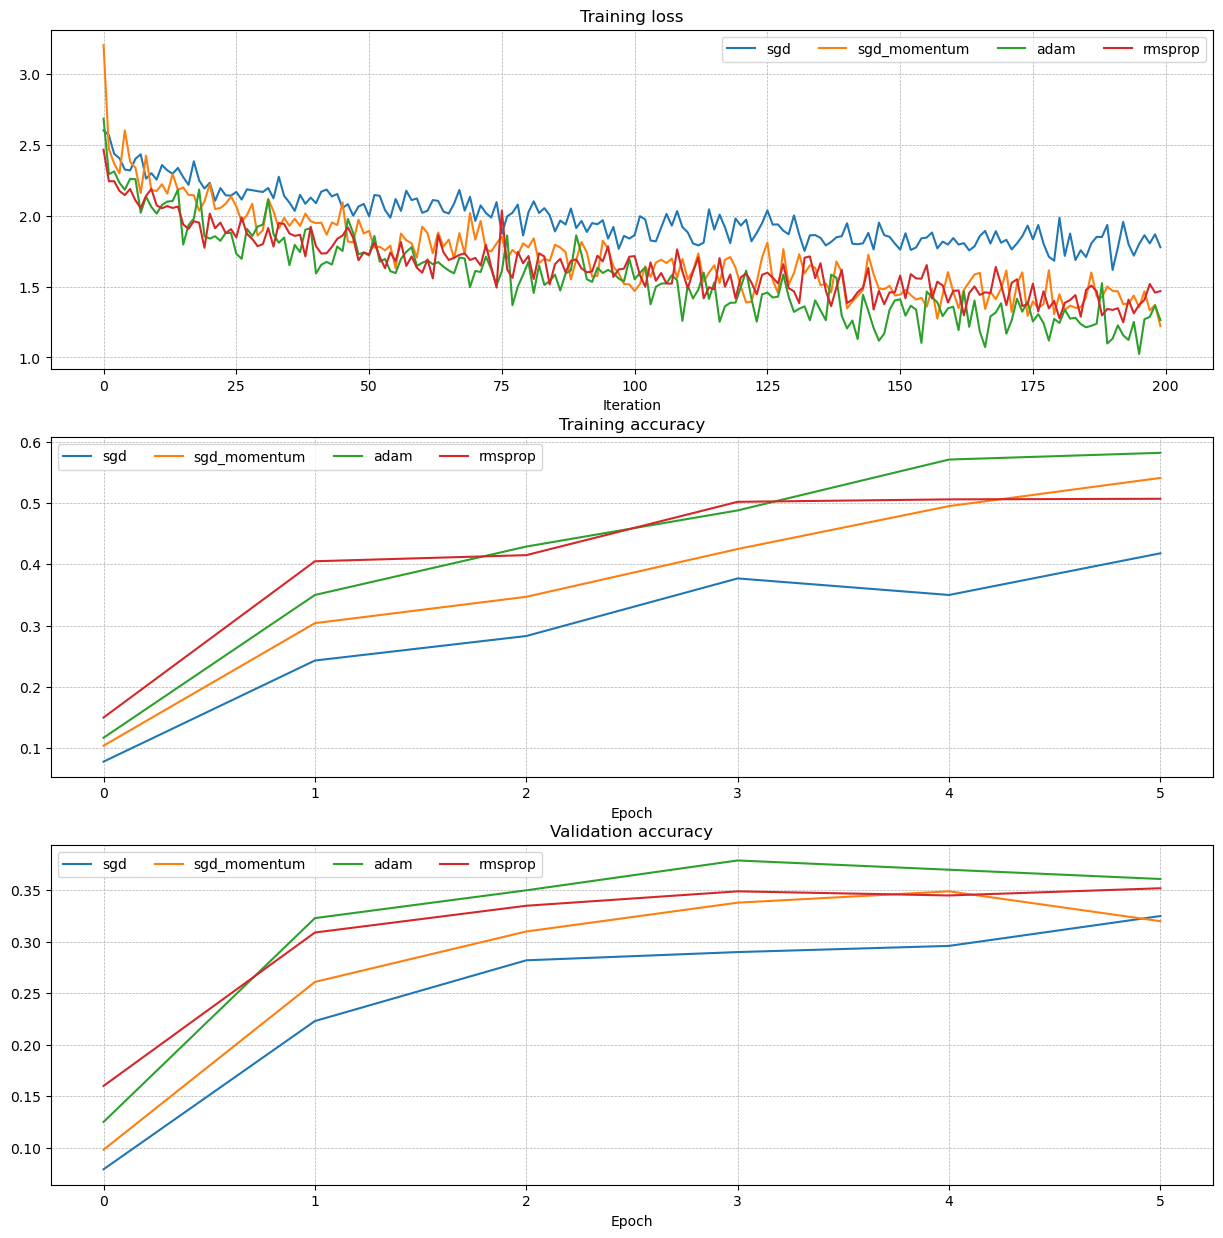

In [35]:
learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3}
for update_rule in ['adam', 'rmsprop']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )
    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': learning_rates[update_rule]},
        verbose=True
    )
    solvers[update_rule] = solver
    solver.train()
    print()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"{update_rule}")

for ax in axes:
    ax.legend(loc='best', ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## Inline Question 2:

AdaGrad, like Adam, is a per-parameter optimization method that uses the following update rule:

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John notices that when he was training a network with AdaGrad that the updates became very small, and that his network was learning slowly. Using your knowledge of the AdaGrad update rule, why do you think the updates would become very small? Would Adam have the same issue?


## Answer:
[FILL THIS IN]




## 内联问题 2：

AdaGrad 和 Adam 类似，是一种逐参数优化方法，它使用以下更新规则：

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John 注意到当他使用 AdaGrad 训练网络时，更新变得非常小，并且他的网络学习速度缓慢。根据你对 AdaGrad 更新规则的了解，你认为为什么更新会变得非常小？Adam 会遇到同样的问题吗？

## 答案：
[由于dw**2>0,会导致cache不断累积增大，而在adam中，对应的参数v采用移动平均的的更新方式，使得v仅反映近期的梯度波动]

# Train a Good Model!
Train the best fully connected model that you can on CIFAR-10, storing your best model in the `best_model` variable. We require you to get at least 50% accuracy on the validation set using a fully connected network.

If you are careful it should be possible to get accuracies above 55%, but we don't require it for this part and won't assign extra credit for doing so. Later in the next assignment, we will ask you to train the best convolutional network that you can on CIFAR-10, and we would prefer that you spend your effort working on convolutional networks rather than fully connected networks.

**Note:** In the next assignment, you will learn techniques like BatchNormalization and Dropout which can help you train powerful models.

# 训练一个优秀的模型！
在CIFAR-10数据集上训练一个尽可能好的全连接模型，并将最佳模型存储在`best_model`变量中。我们要求您使用全连接网络在验证集上至少达到50%的准确率。

如果您足够细心，应该能够得到超过55%的准确率，但对于本部分任务我们并没有这样的要求，也不会因为做到这一点而给予额外加分。在下一项作业中，我们将要求您在CIFAR-10数据集上训练一个尽可能好的卷积网络，我们更希望您将精力投入到卷积网络的训练上，而不是全连接网络。

**注意：** 在下一项作业中，您将学习到批归一化和Dropout等技术，这些技术可以帮助您训练出强大的模型。

(Iteration 1 / 4900) loss: 2.318183
(Epoch 0 / 20) train acc: 0.148000; val_acc: 0.186000
(Iteration 101 / 4900) loss: 1.634686
(Iteration 201 / 4900) loss: 1.692234
(Epoch 1 / 20) train acc: 0.466000; val_acc: 0.447000
(Iteration 301 / 4900) loss: 1.625785
(Iteration 401 / 4900) loss: 1.467201
(Epoch 2 / 20) train acc: 0.508000; val_acc: 0.488000
(Iteration 501 / 4900) loss: 1.535469
(Iteration 601 / 4900) loss: 1.448302
(Iteration 701 / 4900) loss: 1.340591
(Epoch 3 / 20) train acc: 0.528000; val_acc: 0.501000
(Iteration 801 / 4900) loss: 1.298738
(Iteration 901 / 4900) loss: 1.244011
(Epoch 4 / 20) train acc: 0.559000; val_acc: 0.506000
(Iteration 1001 / 4900) loss: 1.461031
(Iteration 1101 / 4900) loss: 1.240158
(Iteration 1201 / 4900) loss: 1.227978
(Epoch 5 / 20) train acc: 0.585000; val_acc: 0.498000
(Iteration 1301 / 4900) loss: 1.366833
(Iteration 1401 / 4900) loss: 1.353645
(Epoch 6 / 20) train acc: 0.596000; val_acc: 0.529000
(Iteration 1501 / 4900) loss: 1.190148
(Iteration

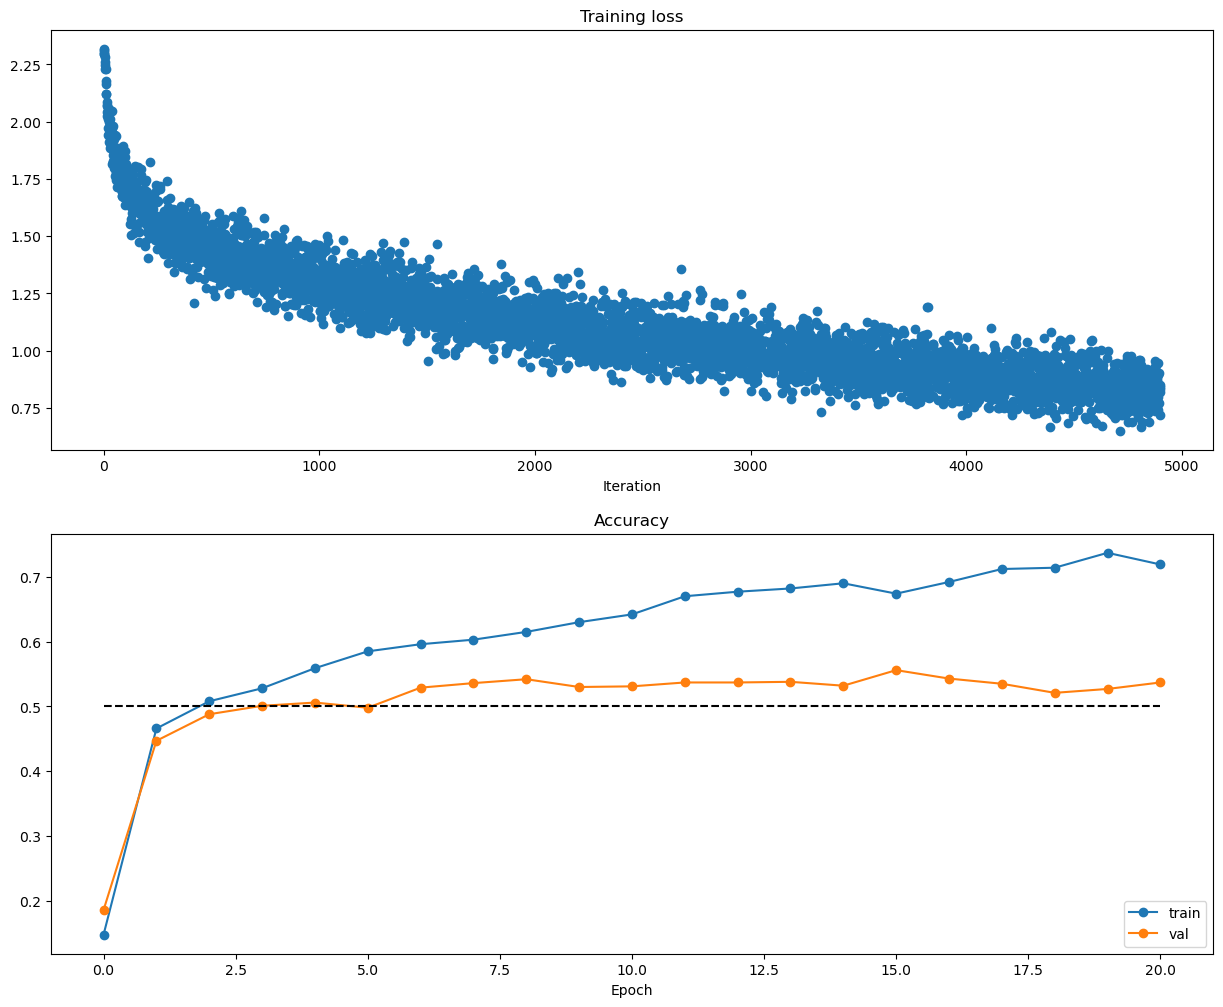

In [46]:
best_model = None

################################################################################
# TODO: Train the best FullyConnectedNet that you can on CIFAR-10. You might   #
# find batch/layer normalization and dropout useful. Store your best model in  #
# the best_model variable.                                                     #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
model = FullyConnectedNet([100,100,100],reg=1e-3)
solver = None

##############################################################################
# TODO: Use a Solver instance to train a TwoLayerNet that achieves about 36% #
# accuracy on the validation set.                                            #
##############################################################################
solver = Solver(model, data,
                  update_rule='adam',
                  optim_config={
                  'learning_rate': 3e-4,
                  },
                  lr_decay=0.95,
                  num_epochs=20, batch_size=200,
                  print_every=100)
solver.train()
plt.subplot(2, 1, 1)
plt.title('Training loss')
plt.plot(solver.loss_history, 'o')
plt.xlabel('Iteration')

plt.subplot(2, 1, 2)
plt.title('Accuracy')
plt.plot(solver.train_acc_history, '-o', label='train')
plt.plot(solver.val_acc_history, '-o', label='val')
plt.plot([0.5] * len(solver.val_acc_history), 'k--')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.gcf().set_size_inches(15, 12)
plt.show()
best_model=model

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
################################################################################
#                              END OF YOUR CODE                                #
################################################################################

# Test Your Model!
Run your best model on the validation and test sets. You should achieve at least 50% accuracy on the validation set and the test set.

In [47]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())

Validation set accuracy:  0.556
Test set accuracy:  0.52
